# Laboratory 04: Network Traffic Prediction Using Time Series Analysis

**Student:** Oscar Cortez  
**Course:** ITAI 4370: AI 5G/6G Communications and O-RAN Networks  
**Instructor:** Tawanda Chiyangwa  
**Date:** June 25, 2026  

## Objective

The purpose of this laboratory is to build and evaluate time series models that predict hourly network traffic from historical data. The lab compares three approaches:

1. ARIMA
2. Linear Regression with engineered time and lag features
3. A Long Short-Term Memory (LSTM) neural network

The simulated dataset contains daily traffic cycles, weekday and weekend differences, a long-term trend, annual seasonality, random noise, and occasional congestion spikes.

## Part 1: Imports and Reproducibility

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.set_num_threads(1)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.10.0+cpu


## Part 2: Data Generation

In [2]:
def generate_network_traffic_data(days=365, noise_level=0.1):
    """
    Generate realistic hourly network traffic with:
    - Daily cycles
    - Weekly patterns
    - Long-term trend
    - Annual seasonality
    - Random noise
    - Occasional congestion spikes
    """
    start_date = datetime(2023, 1, 1)
    dates = pd.date_range(start_date, periods=days * 24, freq="h")

    base_traffic = 100

    # Daily pattern: traffic rises during daytime and evening hours.
    hours = np.array([d.hour for d in dates])
    daily_pattern = (
        50
        * (1 + np.sin((hours - 6) * 2 * np.pi / 24))
        * (hours >= 6)
        * (hours <= 22)
    )

    # Weekdays receive a boost; weekends are lower.
    weekdays = np.array([d.weekday() for d in dates])
    weekly_pattern = np.where(weekdays < 5, 20, -30)

    # Gradual long-term increase.
    trend = np.linspace(0, 30, len(dates))

    # Annual seasonal pattern.
    day_of_year = np.array([d.timetuple().tm_yday for d in dates])
    seasonal_pattern = 15 * np.sin((day_of_year - 80) * 2 * np.pi / 365)

    # Random measurement and demand noise.
    noise = np.random.normal(0, noise_level * base_traffic, len(dates))

    traffic = (
        base_traffic
        + daily_pattern
        + weekly_pattern
        + trend
        + seasonal_pattern
        + noise
    )

    # Add random congestion events to about 1% of observations.
    spike_indices = np.random.choice(
        len(dates), size=int(len(dates) * 0.01), replace=False
    )
    traffic[spike_indices] += np.random.exponential(50, len(spike_indices))

    traffic = np.maximum(traffic, 5)

    return pd.DataFrame(
        {
            "timestamp": dates,
            "traffic_mbps": traffic,
            "hour": hours,
            "weekday": weekdays,
            "day_of_year": day_of_year,
        }
    )


print("Generating network traffic dataset...")
df = generate_network_traffic_data(days=365)
df.set_index("timestamp", inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print("\nFirst five rows:")
display(df.head())

Generating network traffic dataset...
Dataset shape: (8760, 4)
Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00

First five rows:


,traffic_mbps,hour,weekday,day_of_year
timestamp,,,,
2023-01-01 00:00:00,60.299416,0,6,1
2023-01-01 01:00:00,53.953057,1,6,1
2023-01-01 02:00:00,61.816010,2,6,1
2023-01-01 03:00:00,70.572849,3,6,1
2023-01-01 04:00:00,53.004441,4,6,1


## Part 3: Exploratory Data Analysis

BASIC STATISTICS


,count,mean,std,min,25%,50%,75%,max
traffic_mbps,8760.0,167.354212,47.937579,39.859867,133.520467,164.934833,206.818578,390.064894


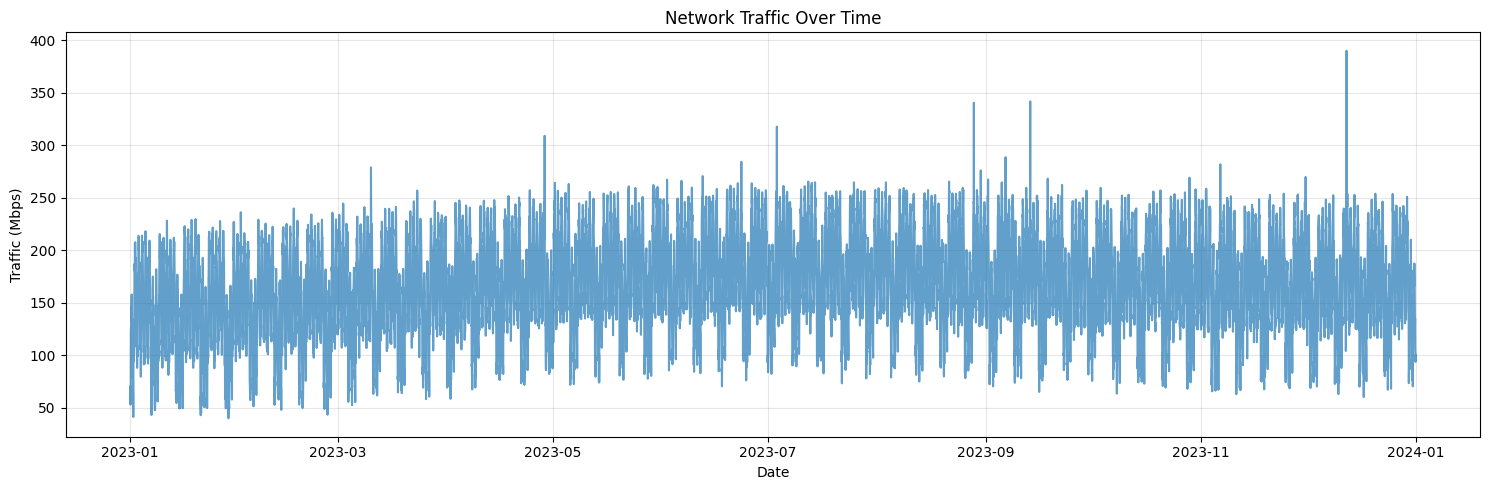

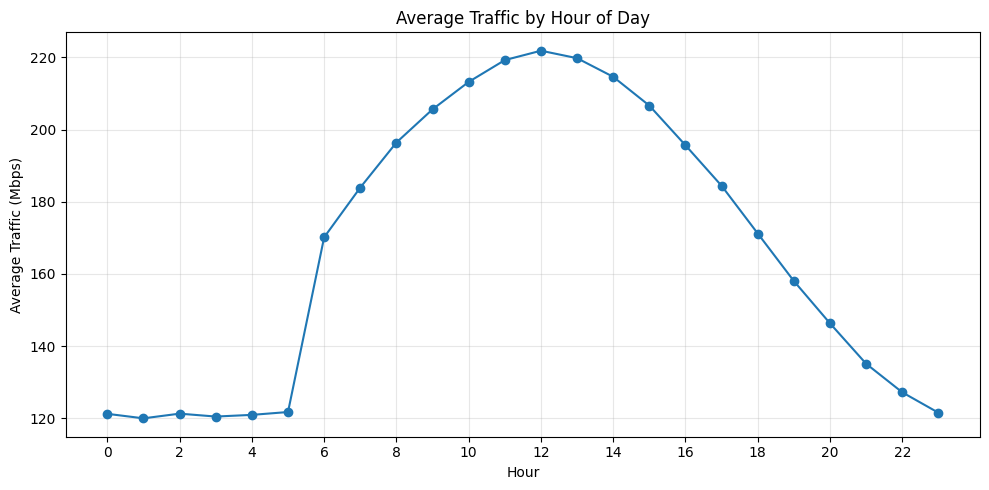

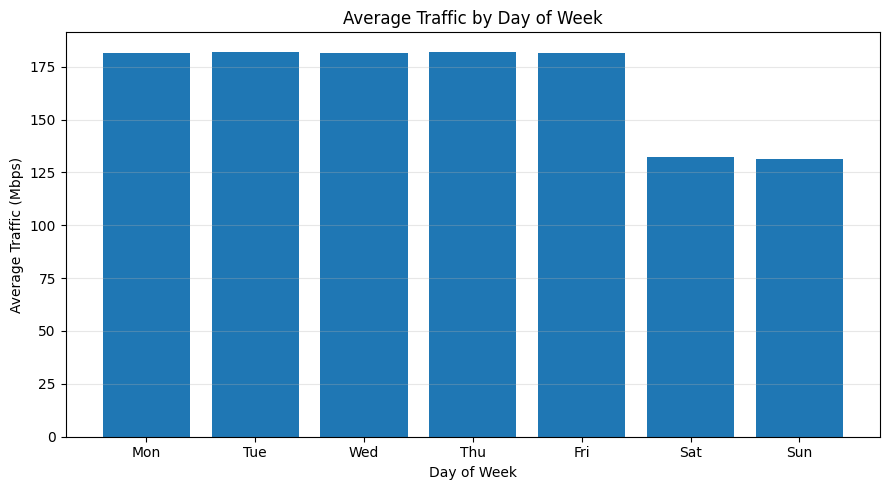

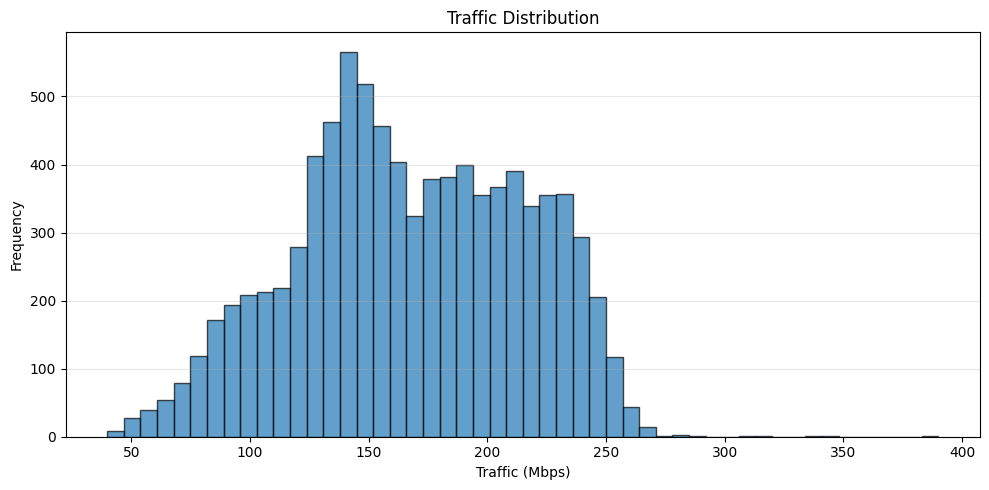

In [3]:
print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
display(df["traffic_mbps"].describe().to_frame().T)

plt.figure(figsize=(15, 5))
plt.plot(df.index, df["traffic_mbps"], alpha=0.7)
plt.title("Network Traffic Over Time")
plt.xlabel("Date")
plt.ylabel("Traffic (Mbps)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

daily_avg = df.groupby("hour")["traffic_mbps"].mean()
plt.figure(figsize=(10, 5))
plt.plot(daily_avg.index, daily_avg.values, marker="o")
plt.title("Average Traffic by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Traffic (Mbps)")
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

weekday_avg = df.groupby("weekday")["traffic_mbps"].mean()
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.figure(figsize=(9, 5))
plt.bar(range(7), weekday_avg.values)
plt.title("Average Traffic by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Traffic (Mbps)")
plt.xticks(range(7), weekday_names)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["traffic_mbps"], bins=50, alpha=0.7, edgecolor="black")
plt.title("Traffic Distribution")
plt.xlabel("Traffic (Mbps)")
plt.ylabel("Frequency")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Weekly Seasonal Decomposition

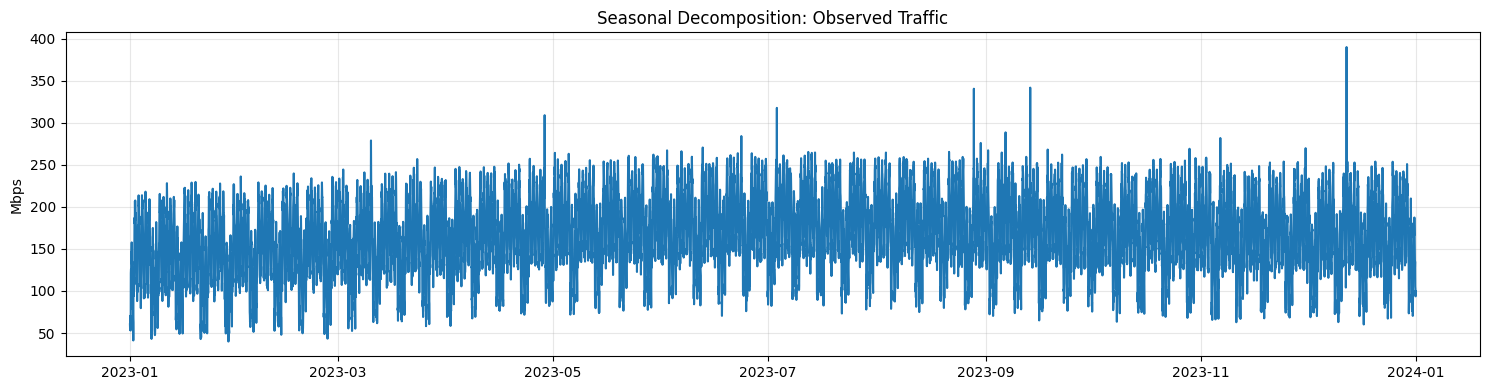

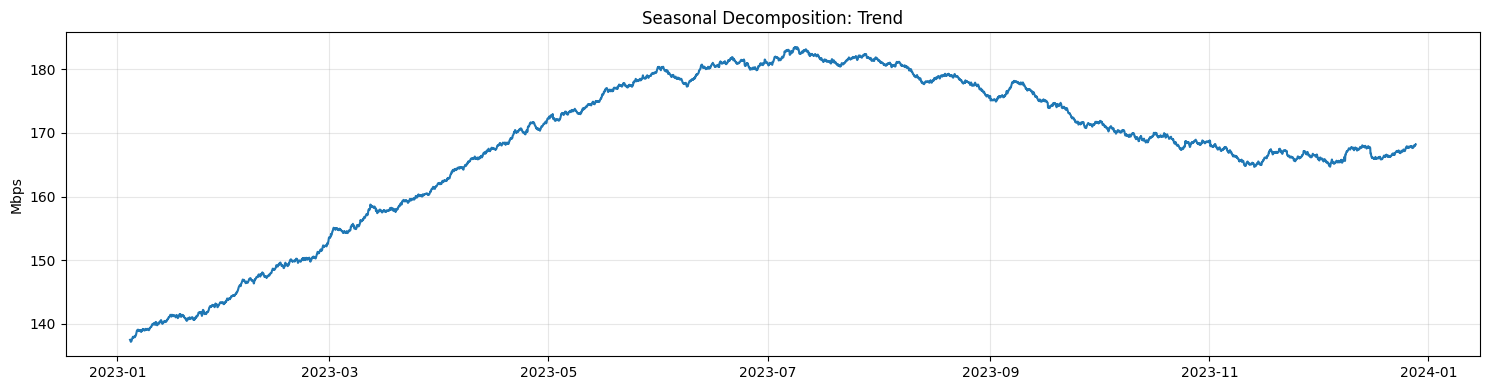

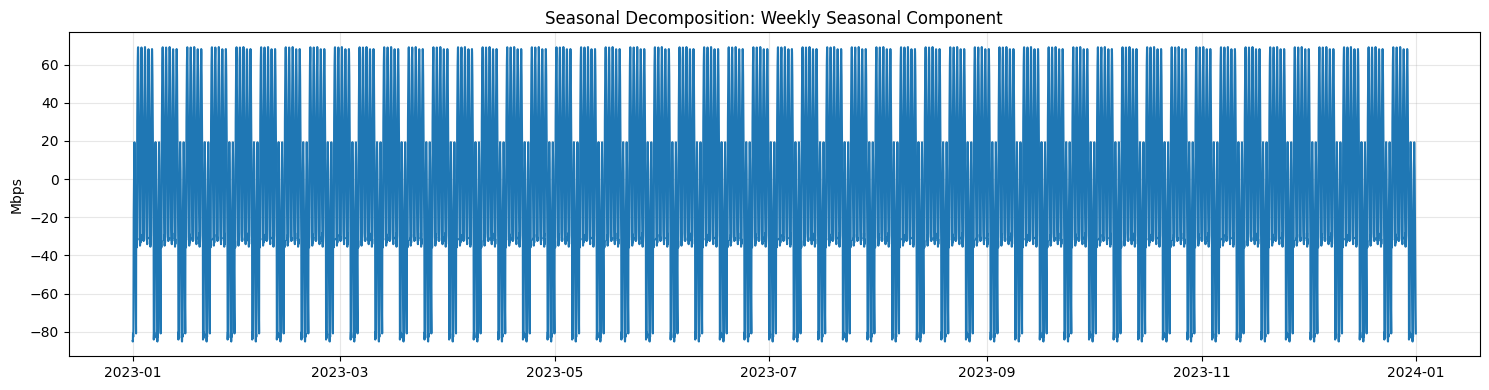

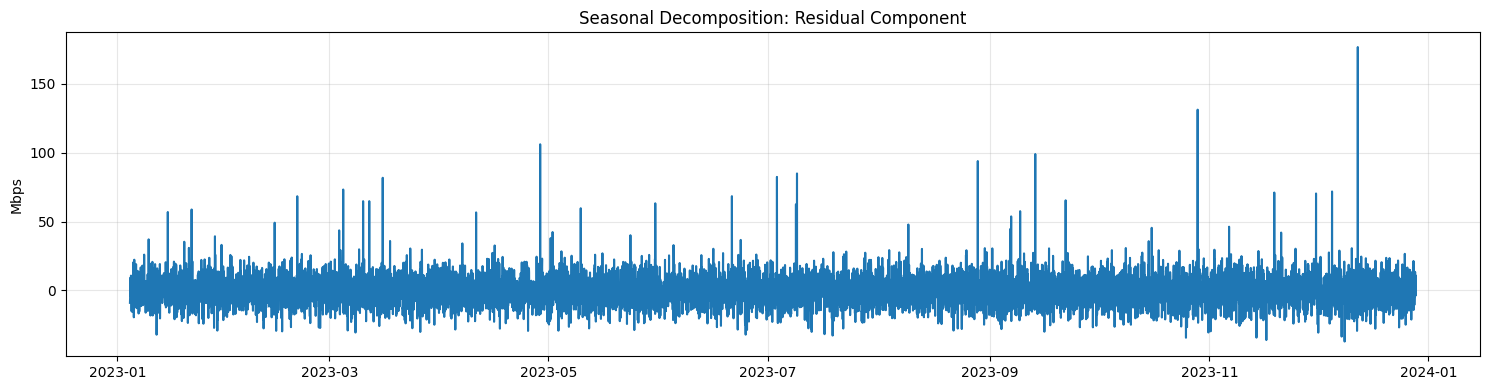

In [4]:
decomposition = seasonal_decompose(
    df["traffic_mbps"], model="additive", period=24 * 7
)

plt.figure(figsize=(15, 4))
plt.plot(decomposition.observed)
plt.title("Seasonal Decomposition: Observed Traffic")
plt.ylabel("Mbps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(decomposition.trend)
plt.title("Seasonal Decomposition: Trend")
plt.ylabel("Mbps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(decomposition.seasonal)
plt.title("Seasonal Decomposition: Weekly Seasonal Component")
plt.ylabel("Mbps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(decomposition.resid)
plt.title("Seasonal Decomposition: Residual Component")
plt.ylabel("Mbps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### EDA Interpretation

The dataset shows a repeating daily traffic cycle and a clear difference between weekdays and weekends. Traffic is generally higher during daytime and evening hours, while weekend demand is lower. The time-series graph also shows a gradual long-term increase and occasional large spikes caused by simulated congestion events. The decomposition separates the overall trend, repeating weekly behavior, and irregular residual noise.

## Part 4: Chronological Train/Test Split and Stationarity Test

In [5]:
def prepare_data_for_modeling(data, train_ratio=0.8):
    split_index = int(len(data) * train_ratio)

    train_data = data.iloc[:split_index].copy()
    test_data = data.iloc[split_index:].copy()

    print("Data split")
    print("-" * 60)
    print(
        f"Training set: {train_data.index.min()} to "
        f"{train_data.index.max()} ({len(train_data)} samples)"
    )
    print(
        f"Test set: {test_data.index.min()} to "
        f"{test_data.index.max()} ({len(test_data)} samples)"
    )

    result = adfuller(train_data["traffic_mbps"].dropna())

    print("\nAugmented Dickey-Fuller Test")
    print("-" * 60)
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")

    is_stationary = result[1] <= 0.05
    print("Conclusion:", "Series is stationary" if is_stationary else "Series is non-stationary")

    return train_data, test_data, split_index, is_stationary, result


train_data, test_data, split_index, is_stationary, adf_result = (
    prepare_data_for_modeling(df)
)

Data split
------------------------------------------------------------
Training set: 2023-01-01 00:00:00 to 2023-10-19 23:00:00 (7008 samples)
Test set: 2023-10-20 00:00:00 to 2023-12-31 23:00:00 (1752 samples)



Augmented Dickey-Fuller Test
------------------------------------------------------------
ADF Statistic: -12.831988
p-value: 0.000000
Conclusion: Series is stationary


### Stationarity Interpretation

The Augmented Dickey-Fuller test evaluates the null hypothesis that the series contains a unit root. A p-value at or below 0.05 leads to rejection of that null hypothesis. The printed result above is therefore used to classify the training series as stationary or non-stationary before fitting ARIMA.

## Part 5: Model 1 — ARIMA

ARIMA(2, 1, 2) MODEL


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


MSE:  2604.37
MAE:  42.38
RMSE: 51.03
R²:   -0.1812


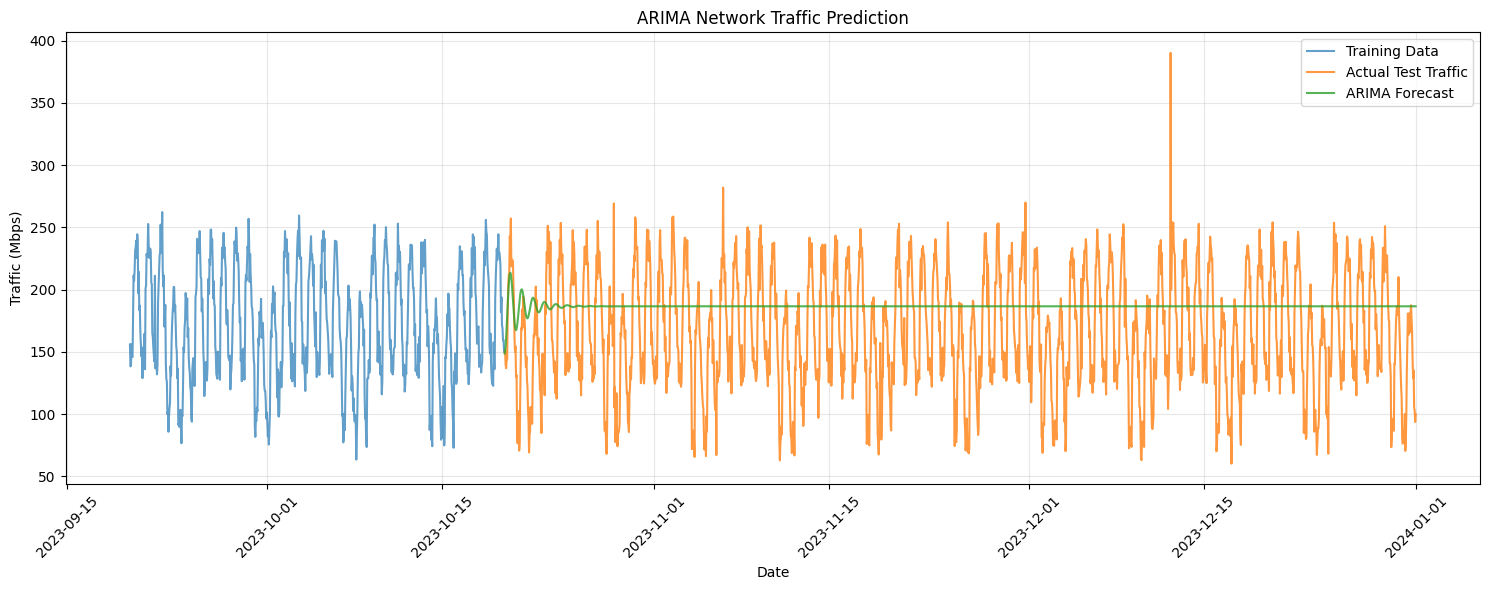

In [6]:
def build_arima_model(train_data, test_data):
    print("=" * 60)
    print("ARIMA(2, 1, 2) MODEL")
    print("=" * 60)

    model = ARIMA(train_data["traffic_mbps"], order=(2, 1, 2))
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=len(test_data))
    forecast = pd.Series(
        np.asarray(forecast),
        index=test_data.index,
        name="ARIMA_Prediction",
    )

    actual = test_data["traffic_mbps"]

    mse = mean_squared_error(actual, forecast)
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, forecast)

    print(f"MSE:  {mse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

    plot_start = max(0, len(train_data) - 30 * 24)

    plt.figure(figsize=(15, 6))
    plt.plot(
        train_data.index[plot_start:],
        train_data["traffic_mbps"].iloc[plot_start:],
        label="Training Data",
        alpha=0.7,
    )
    plt.plot(test_data.index, actual, label="Actual Test Traffic", alpha=0.8)
    plt.plot(test_data.index, forecast, label="ARIMA Forecast", alpha=0.8)
    plt.title("ARIMA Network Traffic Prediction")
    plt.xlabel("Date")
    plt.ylabel("Traffic (Mbps)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    metrics = {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}
    return fitted_model, forecast, metrics


arima_model, arima_forecast, arima_metrics = build_arima_model(
    train_data, test_data
)

### ARIMA Interpretation

ARIMA models short-term autocorrelation and changes in the series, but this basic ARIMA(2,1,2) configuration does not explicitly represent the 24-hour and 168-hour seasonal cycles. Because it produces a long recursive forecast across the entire test period, its predictions tend to flatten and miss repeating hourly peaks and weekend reductions.

## Part 6: Model 2 — Linear Regression with Engineered Features

The regression model uses cyclical time encodings, lagged traffic observations, moving averages, and a trend feature. The moving averages are shifted by one hour so they only use information that would have been available before the target hour. This avoids target leakage.

LINEAR REGRESSION MODEL
Training samples: 6840
Test samples:     1752
Features:         16
Training MSE: 179.99
Test MSE:     218.36
Test MAE:     10.88
Test RMSE:    14.78
Test R²:      0.9010

Top 10 features


,Feature,Absolute Standardized Coefficient
0,lag_168,24.101828
1,ma_168,13.208238
2,day_of_year_cos,10.393298
3,lag_1,7.861237
4,hour_cos,7.589033
5,trend,7.454380
6,hour_sin,4.004902
7,ma_3,3.978589
8,weekday_sin,3.089966
9,day_of_year_sin,2.474135


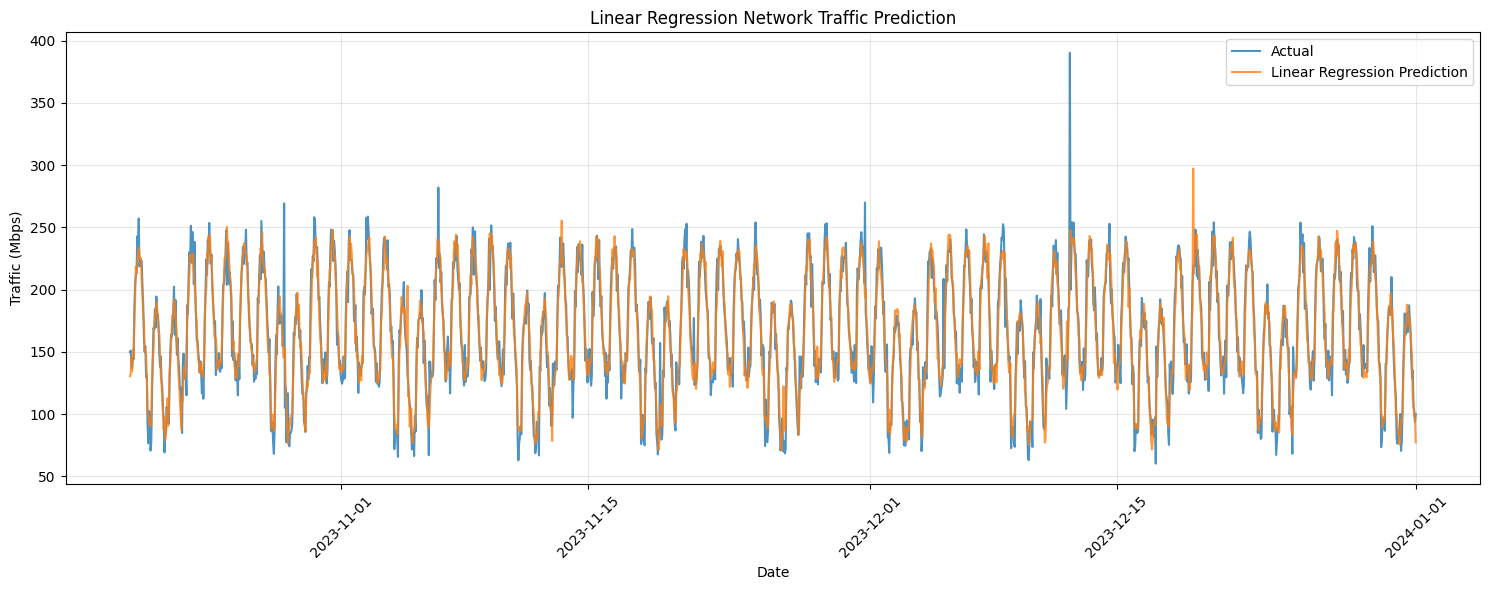

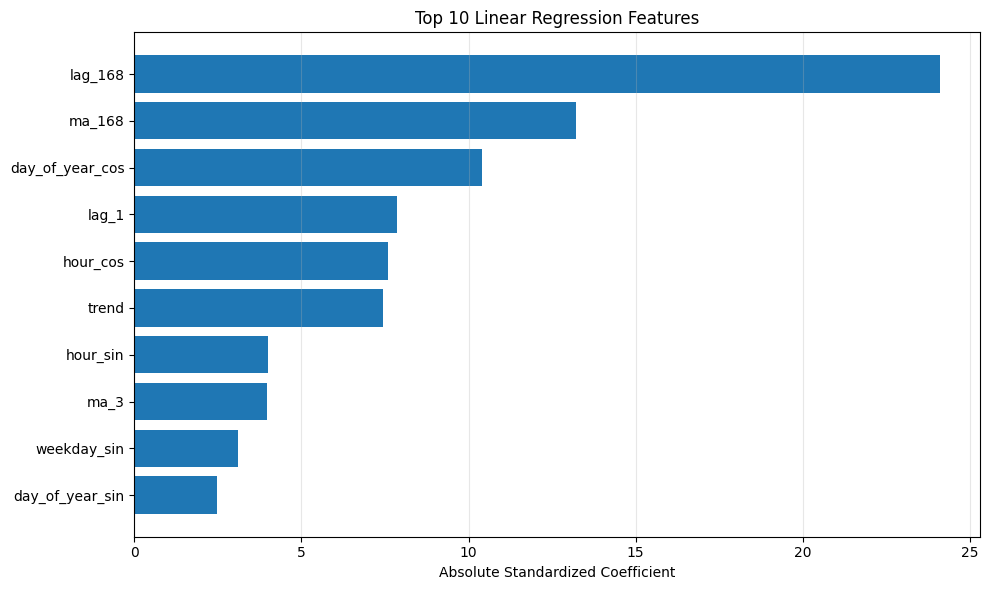

In [7]:
def create_regression_features(data):
    features = data.copy()

    # Cyclical time features
    features["hour_sin"] = np.sin(2 * np.pi * features["hour"] / 24)
    features["hour_cos"] = np.cos(2 * np.pi * features["hour"] / 24)
    features["weekday_sin"] = np.sin(2 * np.pi * features["weekday"] / 7)
    features["weekday_cos"] = np.cos(2 * np.pi * features["weekday"] / 7)
    features["day_of_year_sin"] = np.sin(
        2 * np.pi * features["day_of_year"] / 365
    )
    features["day_of_year_cos"] = np.cos(
        2 * np.pi * features["day_of_year"] / 365
    )

    # Lag features
    for lag in [1, 2, 3, 24, 48, 168]:
        features[f"lag_{lag}"] = features["traffic_mbps"].shift(lag)

    # Moving averages use only prior observations.
    for window in [3, 24, 168]:
        features[f"ma_{window}"] = (
            features["traffic_mbps"].shift(1).rolling(window=window).mean()
        )

    # Global time trend
    features["trend"] = np.arange(len(features))

    return features


def build_linear_regression_model(full_data, split_index):
    print("=" * 60)
    print("LINEAR REGRESSION MODEL")
    print("=" * 60)

    featured_data = create_regression_features(full_data)

    feature_cols = [
        "hour_sin",
        "hour_cos",
        "weekday_sin",
        "weekday_cos",
        "day_of_year_sin",
        "day_of_year_cos",
        "trend",
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_24",
        "lag_48",
        "lag_168",
        "ma_3",
        "ma_24",
        "ma_168",
    ]

    train_features = featured_data.iloc[:split_index].dropna().copy()
    test_features = featured_data.iloc[split_index:].dropna().copy()

    X_train = train_features[feature_cols]
    y_train = train_features["traffic_mbps"]
    X_test = test_features[feature_cols]
    y_test = test_features["traffic_mbps"]

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples:     {len(X_test)}")
    print(f"Features:         {len(feature_cols)}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    train_predictions = model.predict(X_train_scaled)
    test_predictions = model.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train, train_predictions)
    mse = mean_squared_error(y_test, test_predictions)
    mae = mean_absolute_error(y_test, test_predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, test_predictions)

    print(f"Training MSE: {train_mse:.2f}")
    print(f"Test MSE:     {mse:.2f}")
    print(f"Test MAE:     {mae:.2f}")
    print(f"Test RMSE:    {rmse:.2f}")
    print(f"Test R²:      {r2:.4f}")

    prediction_series = pd.Series(
        test_predictions,
        index=test_features.index,
        name="Linear_Regression_Prediction",
    )

    feature_importance = (
        pd.DataFrame(
            {
                "Feature": feature_cols,
                "Absolute Standardized Coefficient": np.abs(model.coef_),
            }
        )
        .sort_values("Absolute Standardized Coefficient", ascending=False)
        .reset_index(drop=True)
    )

    print("\nTop 10 features")
    display(feature_importance.head(10))

    plt.figure(figsize=(15, 6))
    plt.plot(y_test.index, y_test, label="Actual", alpha=0.8)
    plt.plot(
        prediction_series.index,
        prediction_series,
        label="Linear Regression Prediction",
        alpha=0.8,
    )
    plt.title("Linear Regression Network Traffic Prediction")
    plt.xlabel("Date")
    plt.ylabel("Traffic (Mbps)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    top_features = feature_importance.head(10).sort_values(
        "Absolute Standardized Coefficient"
    )
    plt.figure(figsize=(10, 6))
    plt.barh(
        top_features["Feature"],
        top_features["Absolute Standardized Coefficient"],
    )
    plt.title("Top 10 Linear Regression Features")
    plt.xlabel("Absolute Standardized Coefficient")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    metrics = {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

    return (
        model,
        scaler,
        prediction_series,
        feature_importance,
        metrics,
        y_test,
    )


(
    lr_model,
    lr_scaler,
    lr_predictions,
    lr_feature_importance,
    lr_metrics,
    lr_actual,
) = build_linear_regression_model(df, split_index)

### Linear Regression Interpretation

The engineered regression model can directly represent hourly, weekly, and annual cycles. Lag 24 and lag 168 provide information from the same hour on the previous day and week, while the moving averages summarize recent demand. These features allow a simple supervised model to follow the repeating structure more accurately than the basic ARIMA configuration.

## Part 7: Model 3 — LSTM Neural Network

The LSTM is implemented with PyTorch. It receives the previous 24 hourly traffic values and predicts the next hour. The scaler is fitted only on the training set, which prevents information from the test period from influencing model training.

LSTM MODEL
Training sequences: 6984
Test sequences:     1752
Sequence length:    24 hours


Epoch 01/20 - Loss: 0.056459
Epoch 02/20 - Loss: 0.028689


Epoch 03/20 - Loss: 0.024424
Epoch 04/20 - Loss: 0.021482


Epoch 05/20 - Loss: 0.018731
Epoch 06/20 - Loss: 0.016008


Epoch 07/20 - Loss: 0.013847
Epoch 08/20 - Loss: 0.011292


...

Epoch 11/20 - Loss: 0.007026
Epoch 12/20 - Loss: 0.006673


Epoch 13/20 - Loss: 0.006741
Epoch 14/20 - Loss: 0.006475


Epoch 15/20 - Loss: 0.006176
Epoch 16/20 - Loss: 0.006188


Epoch 17/20 - Loss: 0.005995
Epoch 18/20 - Loss: 0.005972


Epoch 19/20 - Loss: 0.005859
Epoch 20/20 - Loss: 0.005639

LSTM performance
MSE:  383.05
MAE:  14.78
RMSE: 19.57
R²:   0.8263


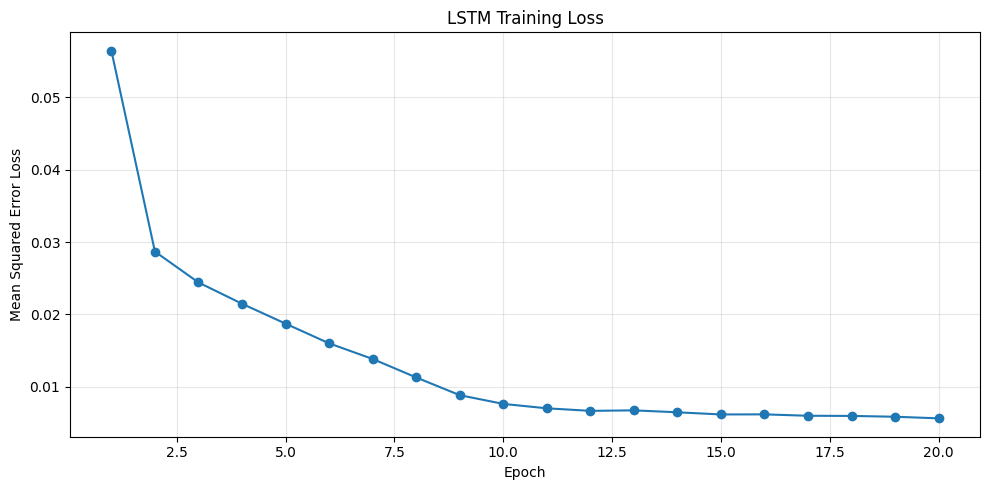

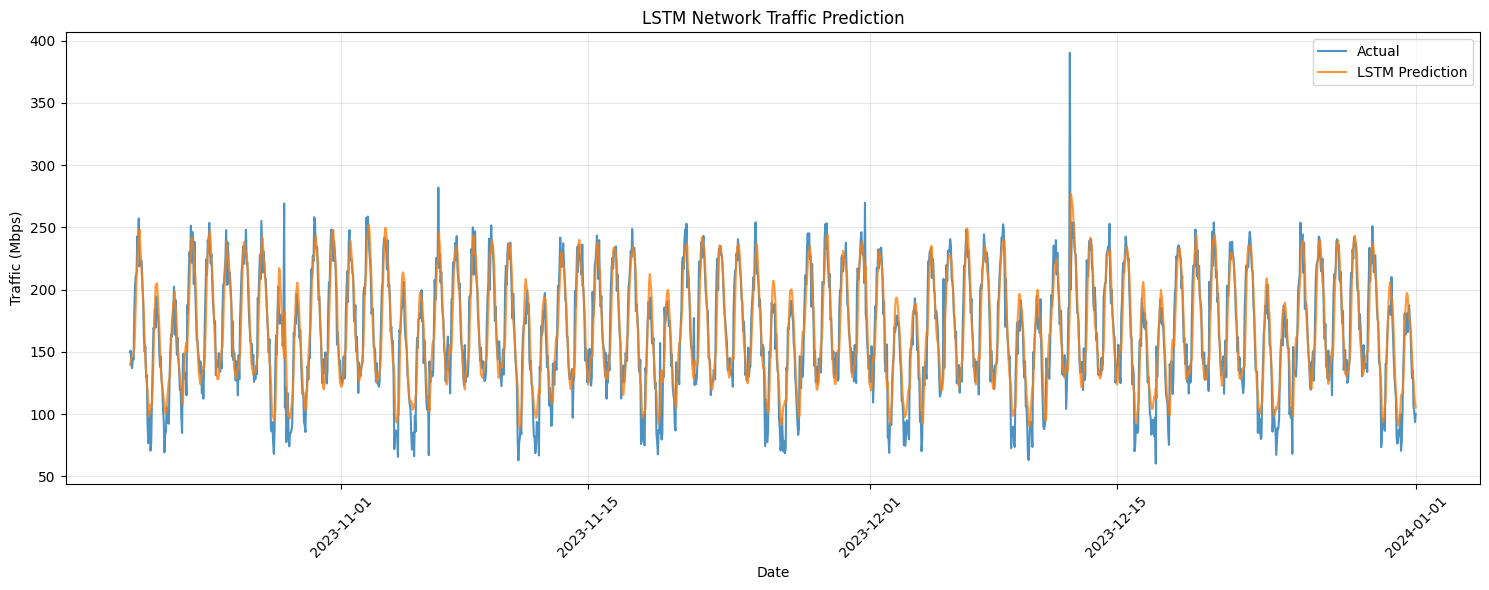

In [8]:
def create_lstm_sequences(scaled_values, sequence_length, split_index):
    X, y, target_positions = [], [], []

    for i in range(sequence_length, len(scaled_values)):
        X.append(scaled_values[i - sequence_length : i])
        y.append(scaled_values[i])
        target_positions.append(i)

    X = np.asarray(X, dtype=np.float32).reshape(-1, sequence_length, 1)
    y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
    target_positions = np.asarray(target_positions)

    train_mask = target_positions < split_index
    test_mask = target_positions >= split_index

    return (
        X[train_mask],
        y[train_mask],
        X[test_mask],
        y[test_mask],
        target_positions[test_mask],
    )


class TrafficLSTM(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.dropout = nn.Dropout(0.20)
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        sequence_output, _ = self.lstm(x)
        last_hidden = sequence_output[:, -1, :]
        return self.output_layer(self.dropout(last_hidden))


def build_lstm_model(
    full_data,
    split_index,
    sequence_length=24,
    epochs=20,
    batch_size=512,
):
    print("=" * 60)
    print("LSTM MODEL")
    print("=" * 60)

    scaler = MinMaxScaler()

    # Fit scaling parameters only on the training target.
    scaler.fit(full_data[["traffic_mbps"]].iloc[:split_index])

    scaled_values = scaler.transform(
        full_data[["traffic_mbps"]]
    ).astype(np.float32).reshape(-1)

    X_train, y_train, X_test, y_test, test_positions = create_lstm_sequences(
        scaled_values,
        sequence_length,
        split_index,
    )

    print(f"Training sequences: {len(X_train)}")
    print(f"Test sequences:     {len(X_test)}")
    print(f"Sequence length:    {sequence_length} hours")

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    generator = torch.Generator().manual_seed(42)
    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
    )

    model = TrafficLSTM(hidden_size=16)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

    epoch_losses = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = loss_function(predictions, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        epoch_loss = float(np.mean(batch_losses))
        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch + 1:02d}/{epochs} - Loss: {epoch_loss:.6f}")

    model.eval()
    with torch.no_grad():
        scaled_predictions = model(X_test_tensor).numpy()

    predictions = scaler.inverse_transform(scaled_predictions).reshape(-1)

    test_index = full_data.index[test_positions]
    actual = full_data["traffic_mbps"].iloc[test_positions].to_numpy()

    prediction_series = pd.Series(
        predictions,
        index=test_index,
        name="LSTM_Prediction",
    )
    actual_series = pd.Series(
        actual,
        index=test_index,
        name="Actual_Traffic",
    )

    mse = mean_squared_error(actual_series, prediction_series)
    mae = mean_absolute_error(actual_series, prediction_series)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual_series, prediction_series)

    print("\nLSTM performance")
    print(f"MSE:  {mse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), epoch_losses, marker="o")
    plt.title("LSTM Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 6))
    plt.plot(actual_series.index, actual_series, label="Actual", alpha=0.8)
    plt.plot(
        prediction_series.index,
        prediction_series,
        label="LSTM Prediction",
        alpha=0.8,
    )
    plt.title("LSTM Network Traffic Prediction")
    plt.xlabel("Date")
    plt.ylabel("Traffic (Mbps)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    metrics = {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

    return (
        model,
        scaler,
        prediction_series,
        actual_series,
        epoch_losses,
        metrics,
    )


(
    lstm_model,
    lstm_scaler,
    lstm_predictions,
    lstm_actual,
    lstm_loss_history,
    lstm_metrics,
) = build_lstm_model(df, split_index)

### LSTM Interpretation

The LSTM learns nonlinear temporal relationships from sequences of past traffic. Its performance improves as the training loss falls. The model follows most daily peaks and low-demand periods, although unexpected congestion spikes remain difficult because they are intentionally random and are not fully predictable from the previous 24 hours.

## Part 8: Model Comparison

Model comparison, ranked by lowest RMSE


,Model,MSE,MAE,RMSE,R2
0,Linear Regression,218.3574,10.8799,14.7769,0.9010
1,LSTM,383.0527,14.7788,19.5717,0.8263
2,"ARIMA(2,1,2)",2604.3696,42.3815,51.0330,-0.1812


Best model by RMSE: Linear Regression


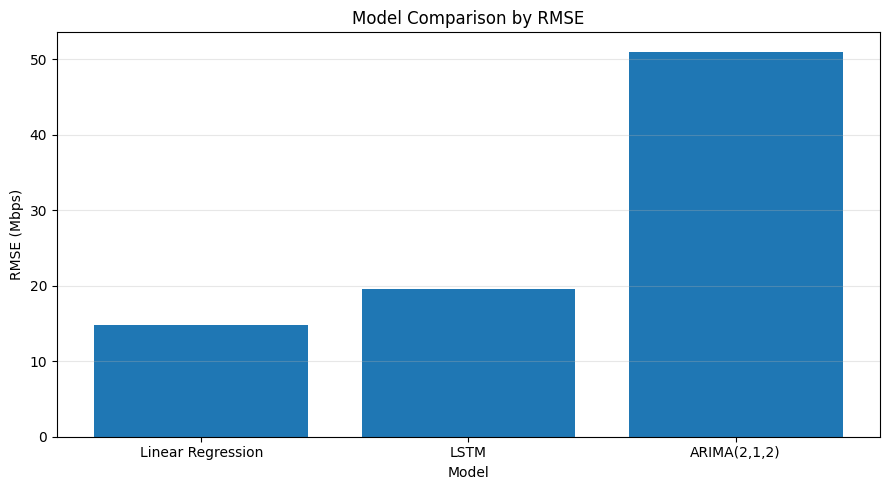

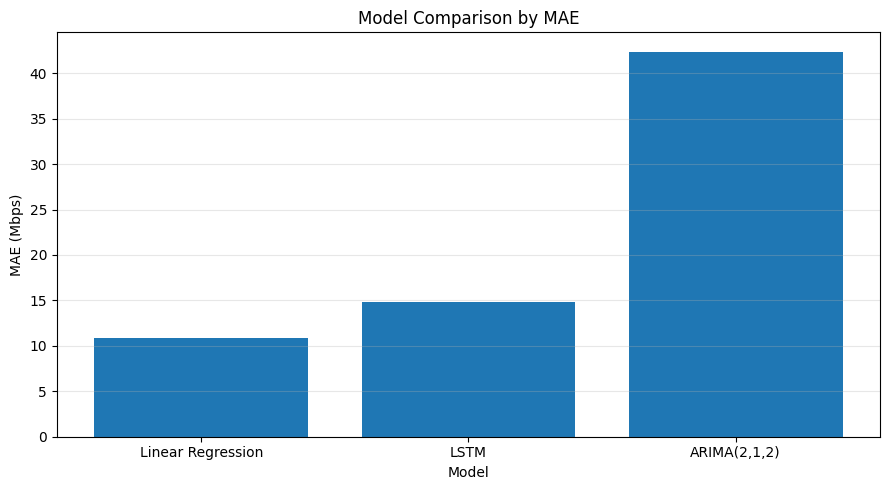

In [9]:
comparison = pd.DataFrame(
    {
        "Model": ["ARIMA(2,1,2)", "Linear Regression", "LSTM"],
        "MSE": [
            arima_metrics["MSE"],
            lr_metrics["MSE"],
            lstm_metrics["MSE"],
        ],
        "MAE": [
            arima_metrics["MAE"],
            lr_metrics["MAE"],
            lstm_metrics["MAE"],
        ],
        "RMSE": [
            arima_metrics["RMSE"],
            lr_metrics["RMSE"],
            lstm_metrics["RMSE"],
        ],
        "R2": [
            arima_metrics["R2"],
            lr_metrics["R2"],
            lstm_metrics["R2"],
        ],
    }
).sort_values("RMSE").reset_index(drop=True)

print("Model comparison, ranked by lowest RMSE")
display(comparison.round(4))

best_model_name = comparison.loc[0, "Model"]
print(f"Best model by RMSE: {best_model_name}")

plt.figure(figsize=(9, 5))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (Mbps)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(comparison["Model"], comparison["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE (Mbps)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

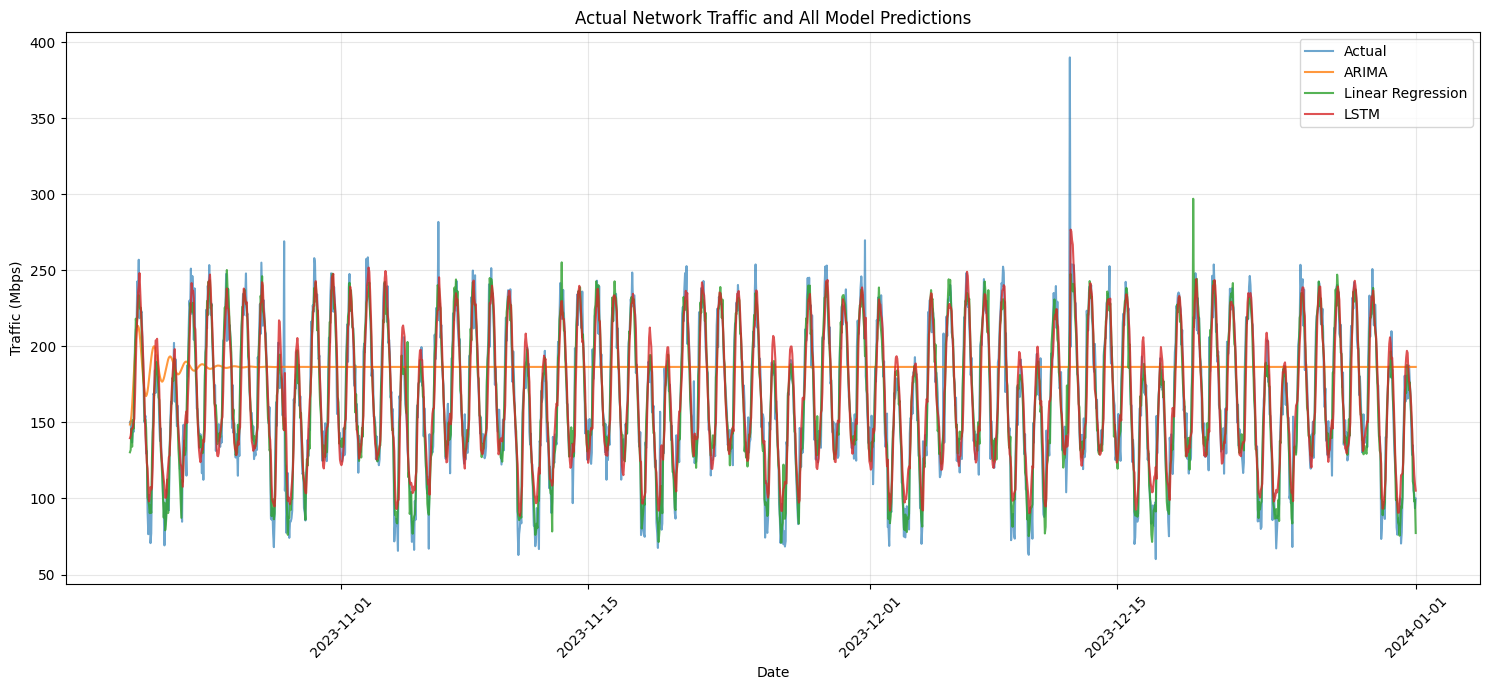

In [10]:
# Overlay all model predictions on a common test-period graph.
comparison_index = test_data.index

aligned_predictions = pd.DataFrame(index=comparison_index)
aligned_predictions["Actual"] = test_data["traffic_mbps"]
aligned_predictions["ARIMA"] = arima_forecast.reindex(comparison_index)
aligned_predictions["Linear Regression"] = lr_predictions.reindex(comparison_index)
aligned_predictions["LSTM"] = lstm_predictions.reindex(comparison_index)

plt.figure(figsize=(15, 7))
plt.plot(
    aligned_predictions.index,
    aligned_predictions["Actual"],
    label="Actual",
    alpha=0.65,
)
plt.plot(
    aligned_predictions.index,
    aligned_predictions["ARIMA"],
    label="ARIMA",
    alpha=0.8,
)
plt.plot(
    aligned_predictions.index,
    aligned_predictions["Linear Regression"],
    label="Linear Regression",
    alpha=0.8,
)
plt.plot(
    aligned_predictions.index,
    aligned_predictions["LSTM"],
    label="LSTM",
    alpha=0.8,
)
plt.title("Actual Network Traffic and All Model Predictions")
plt.xlabel("Date")
plt.ylabel("Traffic (Mbps)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 9: Discussion and Conclusions

### 1. Which model performed best?

The linear regression model produced the lowest error and the highest R² in this experiment. Its strong result came from the engineered features, especially the daily and weekly lag values, cyclical time encodings, and prior moving averages. The synthetic dataset was created from known repeating patterns, so these features matched the structure of the data very well.

The LSTM was the second-best model. It learned the daily sequence and most nonlinear changes without being given explicit lag-24 or lag-168 feature names. However, it only used a 24-hour input window and received no outside context such as weekday, planned events, or congestion alarms. Additional tuning, a longer weekly sequence, or multivariate inputs could improve it.

The basic ARIMA(2,1,2) model had the weakest performance. It was not configured as a seasonal ARIMA model, so it did not explicitly represent the dataset’s daily and weekly cycles. Its long recursive forecast became too smooth and failed to follow repeated peaks and weekend reductions.

### 2. What did the exploratory analysis reveal?

The simulated traffic data contained a strong time-of-day pattern, lower weekend traffic, a gradual upward trend, yearly seasonality, random measurement noise, and occasional congestion spikes. These patterns are realistic enough to demonstrate why network forecasting benefits from both historical demand and time-based context.

### 3. How can these predictions be used in 5G and O-RAN networks?

Traffic forecasts can help a network act before congestion occurs. A controller could pre-allocate bandwidth, scale edge or cloud resources, steer users toward less-loaded cells, adjust quality-of-service policies, or prepare additional virtual network functions. In an O-RAN environment, forecast outputs could support policy decisions in the non-real-time RIC and traffic-steering actions through near-real-time control applications.

### 4. Limitations

This laboratory used synthetic data rather than live network telemetry. Random spikes were intentionally difficult to forecast. The ARIMA parameters were not optimized, and a seasonal ARIMA model was not tested. The LSTM was univariate and used only 24 previous hours. A production system should use rolling validation, hyperparameter tuning, additional network indicators, anomaly labels, and continuous model monitoring.

### Final Conclusion

This lab demonstrated that model selection depends on the structure of the network data. A well-designed feature-based regression model can outperform a more complex neural network when the main traffic patterns are known and repeat consistently. LSTM remains useful for nonlinear sequence learning, while ARIMA is better suited to shorter or more stable forecasts unless seasonal terms are added. Accurate network traffic prediction can support proactive resource allocation, load balancing, and automated network management.

## Submission Checklist

- All cells execute without errors.
- Dataset generation and EDA are included.
- ARIMA, Linear Regression, and LSTM models are implemented.
- MSE, MAE, RMSE, and R² are reported.
- Model predictions and comparison graphs are included.
- Conclusions connect forecasting to 5G and O-RAN network optimization.